In [124]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

In [125]:
# try to plot the test case
experiment_dir = Path("buoy_tracking_data/experiments/experiment_live_20260522_160512")
filename = experiment_dir / "tracking_data_cog.csv"

In [126]:
df = pd.read_csv(filename)

print(f"File: {filename}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

display(df.head())

File: buoy_tracking_data/experiments/experiment_live_20260522_160512/tracking_data_cog.csv
Rows: 407
Columns: 25


,Date,Time,Buoy_ID,LED_On,Ref_Marker_Frame_Detected,CoG_Pos_X_Rel,CoG_Pos_Y_Rel,CoG_Pos_Z_Rel,CoG_Rot_X_Rel_deg,CoG_Rot_Y_Rel_deg,...,CoG_Pos_X_Cam,CoG_Pos_Y_Cam,CoG_Pos_Z_Cam,CoG_Rot_X_Cam_deg,CoG_Rot_Y_Cam_deg,CoG_Rot_Z_Cam_deg,CoG_Quat_X_Cam,CoG_Quat_Y_Cam,CoG_Quat_Z_Cam,CoG_Quat_W_Cam
0,2026-05-22,16:05:14.995,10,0,0,NaN,NaN,NaN,NaN,NaN,...,0.036283,0.001414,0.445340,-173.892,-1.249,54.877,-0.885924,-0.460632,0.014890,0.052296
1,2026-05-22,16:05:15.160,10,0,0,NaN,NaN,NaN,NaN,NaN,...,0.034360,0.002737,0.437558,-175.121,0.378,43.383,-0.928393,-0.369139,0.018794,0.038328
2,2026-05-22,16:05:15.292,10,0,0,NaN,NaN,NaN,NaN,NaN,...,0.033875,0.002538,0.437229,-175.366,-0.555,47.919,-0.912996,-0.405931,0.011998,0.038911
3,2026-05-22,16:05:15.421,10,0,0,NaN,NaN,NaN,NaN,NaN,...,0.034753,0.002700,0.437037,-174.585,-0.559,58.153,-0.872873,-0.485631,0.018696,0.043653
4,2026-05-22,16:05:15.557,10,0,0,NaN,NaN,NaN,NaN,NaN,...,0.033950,0.002348,0.437066,-175.130,-0.946,51.051,-0.901398,-0.430824,0.010863,0.041892


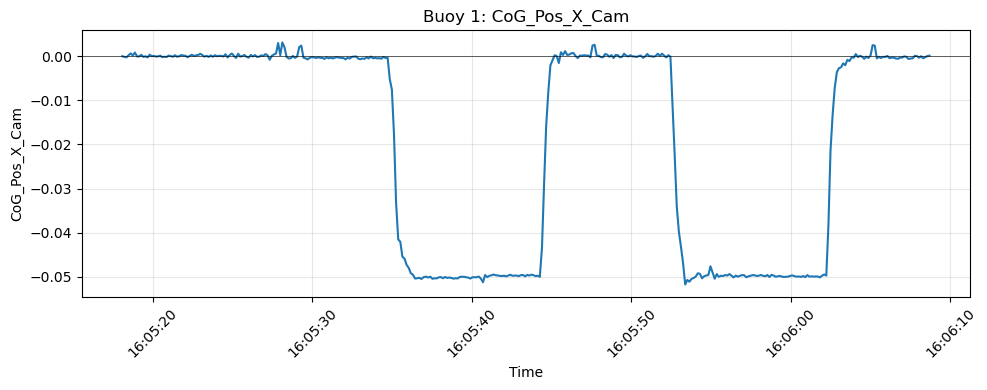

In [127]:
buoy_1 = df[df["Buoy_ID"] == 10].copy()
buoy_1["DateTime"] = pd.to_datetime(buoy_1["Date"] + " " + buoy_1["Time"])

#buoy_2 = df[df["Buoy_ID"] == 2].copy()
#buoy_2["DateTime"] = pd.to_datetime(buoy_2["Date"] + " " + buoy_2["Time"])

# Edit these to constrain the plot window. Use None for no limit.
start_time = "2026-05-22 16:05:18"
end_time = "2026-05-22 16:07:59"

plot_df_1 = buoy_1.copy()
#plot_df_2 = buoy_2.copy()
if start_time is not None:
    plot_df_1 = plot_df_1[plot_df_1["DateTime"] >= pd.to_datetime(start_time)]
    #plot_df_2 = plot_df_2[plot_df_2["DateTime"] >= pd.to_datetime(start_time)]
if end_time is not None:
    plot_df_1 = plot_df_1[plot_df_1["DateTime"] <= pd.to_datetime(end_time)]
    #plot_df_2 = plot_df_2[plot_df_2["DateTime"] <= pd.to_datetime(end_time)]

# Shift so first value of buoy 1 becomes zero
y0 = plot_df_1["CoG_Pos_X_Cam"].iloc[0]
plot_df_1["CoG_Pos_X_Cam_shifted"] = plot_df_1["CoG_Pos_X_Cam"] - y0
#plot_df_2["CoG_Pos_Y_Cam_shifted"] = plot_df_2["CoG_Pos_Y_Cam"] - y0


plt.figure(figsize=(10, 4))
plt.plot(plot_df_1["DateTime"], plot_df_1["CoG_Pos_X_Cam_shifted"])
#plt.plot(plot_df_2["DateTime"], plot_df_2["CoG_Pos_Y_Cam_shifted"])
plt.axhline(0, color='k', linewidth=0.7, alpha=0.6)
#plt.axhline(-0.2, color='k', linewidth=0.7, alpha=0.6)
plt.xlabel("Time")
plt.ylabel("CoG_Pos_X_Cam")
plt.title("Buoy 1: CoG_Pos_X_Cam")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/validaitionOctogon')

Loaded 4 still-test files, 1,648 rows


CoG_Pos_X_Cam           CoG_Pos_Y_Cam  \
                                         mean       std          mean   
Experiment                                                              
experiment_live_20260523_162643     -0.006241  0.000194      0.017682   
experiment_live_20260523_162832     -0.006258  0.000152      0.017807   
experiment_live_20260523_162921     -0.006183  0.000209      0.017696   
experiment_live_20260523_163353     -0.006152  0.000128      0.018082   

                                          CoG_Pos_Z_Cam            
                                      std          mean       std  
Experiment                                                         
experiment_live_20260523_162643  0.000259      0.331572  0.000746  
experiment_live_20260523_162832  0.000147      0.331223  0.000133  
experiment_live_20260523_162921  0.000198      0.331247  0.000266  
experiment_live_20260523_163353  0.000174      0.331132  0.000152

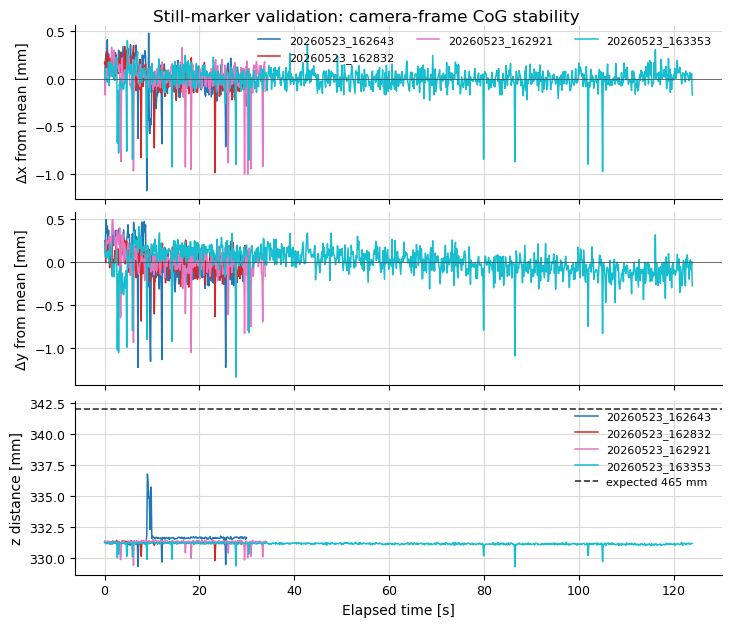

Total CoG distance from camera [m]
                                     mean       std       min       max
Experiment                                                             
experiment_live_20260523_162643  0.332101  0.000744  0.329783  0.337304
experiment_live_20260523_162832  0.331761  0.000135  0.330313  0.331951
experiment_live_20260523_162921  0.331777  0.000270  0.329912  0.332036
experiment_live_20260523_163353  0.331683  0.000157  0.329789  0.331878


In [128]:
# VALIDATION: STILL TESTS. RAN THREE VIDEOS WHERE BUOY IS LEFT STILL. TRYING TO SEE THE ERROR IN STILL MOTION

still_dir = Path("buoy_tracking_data/validation_experiments/still_test_A4")
csv_files = sorted(still_dir.glob("*/tracking_data_cog.csv"))

still_dfs = []
for csv_file in csv_files:
    temp = pd.read_csv(csv_file)
    temp["Experiment"] = csv_file.parent.name
    temp["DateTime"] = pd.to_datetime(temp["Date"] + " " + temp["Time"])
    temp["Elapsed_s"] = (temp["DateTime"] - temp["DateTime"].iloc[0]).dt.total_seconds()
    still_dfs.append(temp)

still_df = pd.concat(still_dfs, ignore_index=True)
skip_seconds = 10
still_df = still_df[still_df["Elapsed_s"] >= skip_seconds].copy()
still_df["Elapsed_s"] = still_df["Elapsed_s"] - skip_seconds

print(f"Loaded {len(csv_files)} still-test files, {len(still_df):,} rows")

summary = still_df.groupby("Experiment")[["CoG_Pos_X_Cam", "CoG_Pos_Y_Cam", "CoG_Pos_Z_Cam"]].agg(["mean", "std"])
display(summary)

expected_distance_mm = (0.297 + 0.045) * 1000
colors = plt.cm.tab10(np.linspace(0, 1, len(csv_files)))

with plt.rc_context({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
}):
    fig, axes = plt.subplots(3, 1, figsize=(7.2, 6.0), sharex=True, constrained_layout=True)
    plot_specs = [
        ("CoG_Pos_X_Cam", "Δx from mean [mm]", True),
        ("CoG_Pos_Y_Cam", "Δy from mean [mm]", True),
        ("CoG_Pos_Z_Cam", "z distance [mm]", False),
    ]

    for ax, (col, ylabel, subtract_mean) in zip(axes, plot_specs):
        for color, (experiment, group) in zip(colors, still_df.groupby("Experiment")):
            y = group[col]
            if subtract_mean:
                y = y - y.mean()
            ax.plot(group["Elapsed_s"], y * 1000, linewidth=1.1, color=color, label=experiment.replace("experiment_live_", ""))

        if col == "CoG_Pos_Z_Cam":
            ax.axhline(expected_distance_mm, linestyle="--", color="0.2", linewidth=1.2, label="expected 465 mm")

        ax.set_ylabel(ylabel)
        ax.grid(True, color="0.85", linewidth=0.8)
        ax.axhline(0, color="0.25", linewidth=0.7, alpha=0.7) if subtract_mean else None

    axes[-1].set_xlabel("Elapsed time [s]")
    axes[0].legend(loc="upper right", frameon=False, ncols=3)
    axes[2].legend(loc="upper right", frameon=False)
    fig.suptitle("Still-marker validation: camera-frame CoG stability", y=1.02)

    figures_dir = Path("figures")
    figures_dir.mkdir(exist_ok=True)
    #fig.savefig(figures_dir / "still_tests_cog_position_publication.png", dpi=300, bbox_inches="tight")
    #fig.savefig(figures_dir / "still_tests_cog_position_publication.pdf", bbox_inches="tight")
    plt.show()

    still_df["CoG_Distance_Cam"] = np.sqrt(
    still_df["CoG_Pos_X_Cam"]**2
    + still_df["CoG_Pos_Y_Cam"]**2
    + still_df["CoG_Pos_Z_Cam"]**2
)

print("Total CoG distance from camera [m]")
print(still_df.groupby("Experiment")["CoG_Distance_Cam"].agg(["mean", "std", "min", "max"]))

Loaded 1 still-test files, 1,038 rows


CoG_Pos_X_Cam           CoG_Pos_Y_Cam  \
                                         mean       std          mean   
Experiment                                                              
experiment_live_20260523_180618       0.00987  0.006471      -0.00576   

                                          CoG_Pos_Z_Cam            
                                      std          mean       std  
Experiment                                                         
experiment_live_20260523_180618  0.001395      0.369688  0.025243

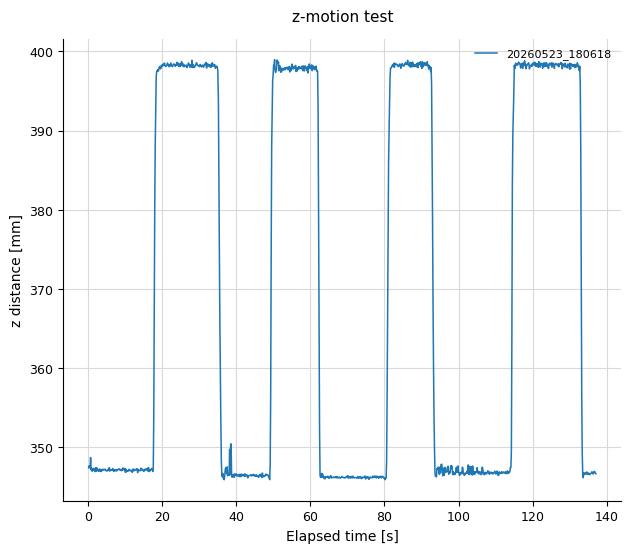

Total CoG distance from camera [m]
                                     mean       std      min      max
Experiment                                                           
experiment_live_20260523_180618  0.369928  0.025188  0.34611  0.39919


In [129]:
# z motion test. Will move the buoy 5 cm towards and from the camera

z_motion_dir = Path("buoy_tracking_data/validation_experiments/z_motion_test")
csv_files = sorted(z_motion_dir.glob("*/tracking_data_cog.csv"))

z_motion_dfs = []
for csv_file in csv_files:
    temp = pd.read_csv(csv_file)
    temp["Experiment"] = csv_file.parent.name
    temp["DateTime"] = pd.to_datetime(temp["Date"] + " " + temp["Time"])
    temp["Elapsed_s"] = (temp["DateTime"] - temp["DateTime"].iloc[0]).dt.total_seconds()
    z_motion_dfs.append(temp)

z_motion_df = pd.concat(z_motion_dfs, ignore_index=True)
skip_seconds = 10
z_motion_df = z_motion_df[z_motion_df["Elapsed_s"] >= skip_seconds].copy()
z_motion_df["Elapsed_s"] = z_motion_df["Elapsed_s"] - skip_seconds

print(f"Loaded {len(csv_files)} still-test files, {len(z_motion_df):,} rows")

summary = z_motion_df.groupby("Experiment")[["CoG_Pos_X_Cam", "CoG_Pos_Y_Cam", "CoG_Pos_Z_Cam"]].agg(["mean", "std"])
display(summary)

colors = plt.cm.tab10(np.linspace(0, 1, len(csv_files)))

with plt.rc_context({
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
}):
    fig = plt.figure(figsize=(7.2, 6.0))
    plot_specs = [
        ("CoG_Pos_Z_Cam", "z distance [mm]", False),
    ]

    for color, (experiment, group) in zip(colors, z_motion_df.groupby("Experiment")):
        y = group[col]
        if subtract_mean:
            y = y - y.mean()
        plt.plot(group["Elapsed_s"], y * 1000, linewidth=1.1, color=color, label=experiment.replace("experiment_live_", ""))

    plt.ylabel(ylabel)
    plt.grid(True, color="0.85", linewidth=0.8)
    plt.axhline(0, color="0.25", linewidth=0.7, alpha=0.7) if subtract_mean else None

    plt.xlabel("Elapsed time [s]")
    plt.legend(loc="upper right", frameon=False, ncols=3)
    plt.legend(loc="upper right", frameon=False)
    plt.title("z-motion test", y=1.02)

    figures_dir = Path("figures")
    figures_dir.mkdir(exist_ok=True)
    #fig.savefig(figures_dir / "still_tests_cog_position_publication.png", dpi=300, bbox_inches="tight")
    #fig.savefig(figures_dir / "still_tests_cog_position_publication.pdf", bbox_inches="tight")
    plt.show()

    z_motion_df["CoG_Distance_Cam"] = np.sqrt(
    z_motion_df["CoG_Pos_X_Cam"]**2
    + z_motion_df["CoG_Pos_Y_Cam"]**2
    + z_motion_df["CoG_Pos_Z_Cam"]**2
)

print("Total CoG distance from camera [m]")
print(z_motion_df.groupby("Experiment")["CoG_Distance_Cam"].agg(["mean", "std", "min", "max"]))

In [131]:
# Robust z-motion step-size check: CoG z only
z_motion_dir = Path("buoy_tracking_data/validation_experiments/z_motion_test")
csv_files = sorted(z_motion_dir.glob("*/tracking_data_cog.csv"))
expected_step_mm = 50
skip_seconds = 10
min_plateau_duration_s = 3


def kmeans_1d_two_levels(values, n_iter=30):
    centers = np.percentile(values, [25, 75]).astype(float)
    for _ in range(n_iter):
        labels = np.argmin(np.abs(values[:, None] - centers[None, :]), axis=1)
        new_centers = centers.copy()
        for label in [0, 1]:
            if np.any(labels == label):
                new_centers[label] = np.median(values[labels == label])
        if np.allclose(new_centers, centers):
            break
        centers = new_centers

    order = np.argsort(centers)
    centers = centers[order]
    remapped = np.zeros_like(labels)
    remapped[labels == order[0]] = 0
    remapped[labels == order[1]] = 1
    return centers, remapped


step_rows = []
for csv_file in csv_files:
    df_z = pd.read_csv(csv_file)
    df_z["DateTime"] = pd.to_datetime(df_z["Date"] + " " + df_z["Time"])
    df_z["Elapsed_s"] = (df_z["DateTime"] - df_z["DateTime"].iloc[0]).dt.total_seconds()
    df_z = df_z[df_z["Elapsed_s"] >= skip_seconds].copy()
    df_z["Elapsed_s"] = df_z["Elapsed_s"] - skip_seconds

    z_mm = (df_z["CoG_Pos_Z_Cam"] * 1000).reset_index(drop=True)
    z_smooth = z_mm.rolling(window=11, center=True, min_periods=1).median().to_numpy()
    centers, labels = kmeans_1d_two_levels(z_smooth)
    level_gap = centers[1] - centers[0]
    stable_tolerance_mm = min(max(5.0, 0.15 * level_gap), 12.0)
    stable_mask = np.abs(z_smooth - centers[labels]) <= stable_tolerance_mm

    stable = df_z.reset_index(drop=True).loc[stable_mask].copy()
    stable["z_mm"] = stable["CoG_Pos_Z_Cam"] * 1000
    stable["level_label"] = labels[stable_mask]

    segments = []
    current_indices = []
    previous_label = None
    previous_time = None
    for idx, row in stable.iterrows():
        label = int(row["level_label"])
        time = row["Elapsed_s"]
        new_segment = previous_label is None or label != previous_label or (time - previous_time) > 2.0
        if new_segment and current_indices:
            segments.append(current_indices)
            current_indices = []
        current_indices.append(idx)
        previous_label = label
        previous_time = time
    if current_indices:
        segments.append(current_indices)

    plateaus = []
    for segment_id, segment_indices in enumerate(segments):
        segment = stable.loc[segment_indices]
        duration = segment["Elapsed_s"].iloc[-1] - segment["Elapsed_s"].iloc[0]
        if duration < min_plateau_duration_s:
            continue

        label = int(segment["level_label"].mode().iloc[0])
        plateaus.append({
            "segment": segment_id,
            "level": "near" if label == 0 else "far",
            "z_mean_mm": segment["z_mm"].mean(),
        })

    for step_id, (a, b) in enumerate(zip(plateaus[:-1], plateaus[1:])):
        if a["level"] == b["level"]:
            continue
        dz_mm = b["z_mean_mm"] - a["z_mean_mm"]
        measured_step_mm = abs(dz_mm)
        step_rows.append({
            "Experiment": csv_file.parent.name,
            "step": step_id,
            "from": a["level"],
            "to": b["level"],
            "z_start_mm": a["z_mean_mm"],
            "z_end_mm": b["z_mean_mm"],
            "dz_mm": dz_mm,
            "measured_step_mm": measured_step_mm,
            "error_from_50_mm": measured_step_mm - expected_step_mm,
        })

step_summary = pd.DataFrame(step_rows)
experiment_summary = (
    step_summary.groupby("Experiment", as_index=False)
    .agg(
        n_steps=("measured_step_mm", "count"),
        average_step_mm=("measured_step_mm", "mean"),
        std_step_mm=("measured_step_mm", "std"),
        average_error_from_50_mm=("error_from_50_mm", "mean"),
    )
)

display(experiment_summary)

,Experiment,step,from,to,z_start_mm,z_end_mm,dz_mm,measured_step_mm,error_from_50_mm
0,experiment_live_20260523_180618,0,near,far,347.209940,398.108915,50.898974,50.898974,0.898974
1,experiment_live_20260523_180618,1,far,near,398.108915,346.673176,-51.435738,51.435738,1.435738
2,experiment_live_20260523_180618,2,near,far,346.673176,397.763295,51.090118,51.090118,1.090118
3,experiment_live_20260523_180618,3,far,near,397.763295,346.272355,-51.490940,51.490940,1.490940
4,experiment_live_20260523_180618,4,near,far,346.272355,398.157954,51.885599,51.885599,1.885599
5,experiment_live_20260523_180618,5,far,near,398.157954,346.971440,-51.186514,51.186514,1.186514
6,experiment_live_20260523_180618,6,near,far,346.971440,398.181297,51.209857,51.209857,1.209857
7,experiment_live_20260523_180618,7,far,near,398.181297,346.796172,-51.385125,51.385125,1.385125
8,AVERAGE,,,,NaN,NaN,NaN,51.322858,1.322858
